# Overlapping Neighborhoods — Parent-Child Role Assignment

**Methodology:** Each well defines its own influence zone. For every well we ask:  
*"Who are this well's neighbors, and what role do I play relative to them?"*

Unlike hard clustering (DBSCAN / graph partitioning), neighborhoods **overlap** — well C can
appear in both A's and E's neighborhoods without transitively linking A and E into one cluster.
This eliminates the chaining problem inherent in density-based clustering.

---

### Neighbor Relationship Types
| Type | Alignment | Bench | Role in Analysis |
|---|---|---|---|
| `parallel_same_bench` | parallel_like | same | **Primary** — drives parent/child/infill assignment |
| `cross_formation` | parallel_like | different | Cross-bench interference (vertical attenuation) |
| `cross_orientation` | perpendicular | any | Cross-azimuth interference (attenuated mechanism) |
| `oblique_same_bench` | oblique | same | Intermediate-angle neighbor |
| `oblique_cross_bench` | oblique | different | Intermediate-angle, cross-bench |

### Role Assignment Logic (parallel same-bench only)
- **Parent**: no older PSB neighbor within threshold → this well was drilled first in its corridor
- **Child** (Gen 1): exactly 1 older PSB neighbor (or ≥1 but within the child window) → parent = nearest older well
- **Infill candidate** (Gen 2+): ≥2 older PSB neighbors within threshold → drilled into a developed corridor

### Distance Thresholds (literature-backed)
| Pair Type | Metric | Threshold | Source |
|---|---|---|---|
| Parallel same-bench | `hz_effective` (crossline mean) | **1,320 ft** | Shell URTeC-2691962; SPE HFTC 2020; Schlumberger Avalon |
| Inner severity zone | `hz_effective` | **660 ft** | SPE HFTC 2020 (confirmed prod damage) |
| Cross-formation parallel | `3D_dist_effective` | **1,320 ft** | URTeC-2669025; URTeC-3722340 (vertical attenuation via 3D) |
| Perpendicular | `hz_effective` (= min_nearest for perp) | **1,000 ft** | Wolfcamp frac half-length 300–1,200 ft; JPT frac hit directionality |
| Oblique | `hz_effective` (= min_nearest for oblique) | **1,100 ft** | Interpolated between parallel and perp |


## 1. Setup & Imports

In [1]:
from __future__ import annotations

import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

warnings.filterwarnings('ignore', category=FutureWarning)
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.1f}'.format)

ROLE_COLORS = {
    'parent':            '#2196F3',  # blue
    'child':             '#FF9800',  # orange
    'infill_candidate':  '#F44336',  # red
    'no_psb_neighbor':   '#9E9E9E',  # grey — in header but no PSB neighbor within threshold
}

print('Imports OK')

Imports OK


## 2. Configuration

All thresholds and file paths in one place. Change values here — nothing below needs editing.

In [2]:
CFG = {
    # ── Neighborhood distance thresholds (feet) ────────────────────────────────
    #
    # PARALLEL SAME-BENCH  (primary parent-child driver)
    #   Upper bound: 1,320 ft (¼ mile).  Shell URTeC-2691962 found no frac hits
    #   at 1,320 ft; SPE HFTC 2020 Delaware Basin: interference at 660 ft,
    #   transition at 990 ft, near-zero at 1,320 ft; Schlumberger Avalon:
    #   5 % prod loss at 1,320 ft vs 24 % at 660 ft.
    'parallel_eps_ft':   1_320,
    #   Inner high-severity zone: documented ~20-24 % production damage.
    'parallel_inner_ft':   660,
    #
    # PERPENDICULAR / CROSS-ORIENTATION
    #   Based on gross hydraulic frac half-length in Wolfcamp / Bone Spring
    #   (effective: 300–700 ft; gross: up to 1,200–1,800 ft per HFTS-1).
    #   Mechanism is weaker than parallel (JPT: "perpendicular wells did not
    #   exhibit changes in performance" — but closest pairs likely outside HFL).
    #   Conservative choice: 1,000 ft (~upper effective propped HFL).
    'perp_eps_ft':       1_000,
    #
    # OBLIQUE (25–65°): interpolated between parallel and perpendicular.
    'oblique_eps_ft':    1_100,
    #
    # CROSS-BENCH PARALLEL
    #   Same horizontal threshold as parallel, but distance metric upgrades to
    #   3D to account for vertical separation between benches (200–600 ft for
    #   Wolfcamp A/B/C). URTeC-2669025; URTeC-3722340 confirm inter-bench
    #   interference is real but attenuated — 3D distance captures this naturally.
    #   NOTE: vertical_dist == |tvd_i - tvd_k| (confirmed identical), so
    #   3D_dist_effective = sqrt(hz_effective² + vertical_dist²) is already
    #   TVD-based — no extra computation needed.
    'cross_bench_eps_ft': 1_320,
    'use_3d_for_cross_bench': True,  # swap hz_effective → 3D_dist_effective

    # ── Temporal role logic ────────────────────────────────────────────────────
    'child_window_months':    18,  # max months after parent to label as Gen-1 child
    'infill_min_older_psb':    2,  # ≥N older PSB neighbors → infill candidate

    # ── Input paths ────────────────────────────────────────────────────────────
    # Parquet (preferred over the _overlap.csv): contains tvd_i / tvd_k per pair
    # and all computed pairs. Filter to reject_reason == '' to keep only valid
    # pairs (excludes no_overlap_x and coarse_far). well_i / well_k are strings.
    # 3D_dist_effective is already TVD-based in both the parquet and the CSV
    # (confirmed: vertical_dist == |tvd_i - tvd_k| to 2 decimal places).
    'ik_pairs_parquet': Path(
        r'C:\Users\ApoorvaSaxen_ct6z7vh\OneDrive - Bandera Group'
        r'\Desktop\Project AP\05. Spacing Study\03. Ring Energy'
        r'\04. Spacing Results\v2\spacing_batch_0000.parquet'
    ),
    'header_path': Path(
        r'C:\Users\ApoorvaSaxen_ct6z7vh\OneDrive - Bandera Group'
        r'\Desktop\Project AP\05. Spacing Study\03. Ring Energy'
        r'\01. Well Header\v2\well_header_spacing_final.csv'
    ),
    'heel_toe_path': Path(
        r'C:\Users\ApoorvaSaxen_ct6z7vh\OneDrive - Bandera Group'
        r'\Desktop\Project AP\05. Spacing Study\03. Ring Energy'
        r'\04. Spacing Results\v2\lateral_heel_toe_midpoints.csv'
    ),
    'avg_spacing_path': Path(
        r'C:\Users\ApoorvaSaxen_ct6z7vh\OneDrive - Bandera Group'
        r'\Desktop\Project AP\05. Spacing Study\03. Ring Energy'
        r'\04. Spacing Results\v2\avg_Spacing_1800H_200V_0.4.csv'
    ),

    # ── Output ─────────────────────────────────────────────────────────────────
    'output_dir': Path(
        r'C:\Users\ApoorvaSaxen_ct6z7vh\OneDrive - Bandera Group'
        r'\Desktop\Project AP\05. Spacing Study\03. Ring Energy'
        r'\04. Spacing Results\v2'
    ),
}

# Validate paths
print('Path check:')
for k, v in CFG.items():
    if isinstance(v, Path):
        ok = v.exists()
        print(f"  {'✓' if ok else '✗ MISSING':<10} {k}: {v.name}")

Path check:
  ✓          ik_pairs_parquet: spacing_batch_0000.parquet
  ✓          header_path: well_header_spacing_final.csv
  ✓          heel_toe_path: lateral_heel_toe_midpoints.csv
  ✓          avg_spacing_path: avg_Spacing_1800H_200V_0.4.csv
  ✓          output_dir: v2


## 3. Data Loading

### 3.1  i-k Spacing Pairs

Loaded from the **parquet** (more complete than the `_overlap.csv`; contains `tvd_i` / `tvd_k`).

Reject-reason filter keeps only valid pairs:
- `''` (empty) → valid pair, distance computed → **keep**
- `no_overlap_x` → laterals don't overlap in the x-direction → reject
- `coarse_far` → pair too far apart for meaningful computation → reject

Key columns used:
- `hz_effective` — alignment-aware distance: crossline-mean for `parallel_like`, min-nearest for `perpendicular`/`oblique`
- `3D_dist_effective` — already TVD-based (`sqrt(hz² + |tvd_i−tvd_k|²)`); used for cross-bench pairs
- `tvd_i`, `tvd_k` — absolute landing TVD per well (same as `vertical_dist = |tvd_i−tvd_k|`)
- `pair_alignment` — `parallel_like` | `perpendicular` | `oblique`

In [3]:
PAIR_COLS = [
    'well_i', 'well_k',
    'bench_i', 'bench_k',
    'hz_effective', '3D_dist_effective', 'vertical_dist',
    'angle_deg', 'pair_alignment',
    'LL_i', 'LL_k',
    'overlap_pct_i', 'overlap_pct_k',
    'min_distance_ft',
    'tvd_i', 'tvd_k',       # absolute landing TVD per well (new in parquet)
    'reject_reason',         # filter column — not kept in final df_pairs
]

df_pairs_raw = pd.read_parquet(CFG['ik_pairs_parquet'], columns=PAIR_COLS)

# Keep only valid pairs (reject_reason == '' means no rejection)
df_pairs = df_pairs_raw[df_pairs_raw['reject_reason'] == ''].drop(columns='reject_reason').copy()

# well_i / well_k are strings in the parquet — normalise to str throughout
# (header uwi is int64; we cast it to str in §3.2 for consistent merging)
df_pairs['well_i'] = df_pairs['well_i'].astype(str)
df_pairs['well_k'] = df_pairs['well_k'].astype(str)

print(f'Parquet total rows:    {len(df_pairs_raw):,}')
print(f'After reject filter:   {len(df_pairs):,}')
print(f'  → no_overlap_x: {(df_pairs_raw.reject_reason == "no_overlap_x").sum():,}')
print(f'  → coarse_far:   {(df_pairs_raw.reject_reason == "coarse_far").sum():,}')
print(f'\nUnique well_i: {df_pairs.well_i.nunique():,} | Unique well_k: {df_pairs.well_k.nunique():,}')
print(f'\npair_alignment breakdown:')
print(df_pairs.pair_alignment.value_counts().to_string())
print(f'\nhz_effective range: {df_pairs.hz_effective.min():.0f} – {df_pairs.hz_effective.max():.0f} ft')
print(f'\ntvd coverage: {df_pairs.tvd_i.notna().sum():,} / {len(df_pairs):,} pairs have tvd_i')
print(f'tvd_i range: {df_pairs.tvd_i.min():.0f} – {df_pairs.tvd_i.max():.0f} ft')

df_pairs.head(3)

Parquet total rows:    118,967
After reject filter:   49,526
  → no_overlap_x: 68,605
  → coarse_far:   836

Unique well_i: 1,883 | Unique well_k: 1,884

pair_alignment breakdown:
pair_alignment
parallel_like    45948
perpendicular     2130
oblique           1448

hz_effective range: 1 – 12352 ft

tvd coverage: 49,526 / 49,526 pairs have tvd_i
tvd_i range: 120 – 16298 ft


,well_i,well_k,bench_i,bench_k,hz_effective,3D_dist_effective,vertical_dist,angle_deg,pair_alignment,LL_i,LL_k,overlap_pct_i,overlap_pct_k,min_distance_ft,tvd_i,tvd_k
25,30025421210000,30025426220000,NM SHELF ALL,NM SHELF ALL,"1,251.2","1,251.5",26.1,2.1,parallel_like,"4,322.0","4,335.5",1.0,1.0,NaN,"5,378.9","5,404.9"
26,30025421210000,30025428730000,NM SHELF ALL,NM SHELF ALL,"1,564.7","1,565.3",46.0,0.4,parallel_like,"4,322.0","4,168.6",1.0,1.0,NaN,"5,378.9","5,332.9"
27,30025421210000,42501367020000,NM SHELF ALL,TEXAS SHELF ALL,"5,824.7","5,824.9",48.6,3.0,parallel_like,"4,322.0","7,871.0",0.9,0.5,NaN,"5,378.9","5,330.3"


### 3.2  Well Header

Provides completion dates (for temporal role assignment), lease names, production metrics, and surface coordinates.

In [4]:
HEADER_COLS = [
    'uwi', 'well_name', 'lease_name', 'operator', 'bench',
    'comp_date', 'first_prod_date',
    'lateral_length_ft', 'tvd',
    'surface_lat', 'surface_lon',
    'fluid_intensity_bbl_per_ft', 'proppant_intensity_lbs_per_ft',
    'cum_oil_180d', 'cum_oil_365d',
    'cum_oil_180d_per_ft', 'cum_oil_365d_per_ft',
    'rsv_cat',
]

df_header = pd.read_csv(CFG['header_path'], usecols=HEADER_COLS)

# Cast uwi to str so it merges cleanly with well_i / well_k (strings in parquet)
df_header['uwi'] = df_header['uwi'].astype(str)

# Parse dates — source has UTC timezone suffix; strip it for simplicity
for col in ['comp_date', 'first_prod_date']:
    df_header[col] = pd.to_datetime(df_header[col], utc=True).dt.tz_convert(None)

print(f'Loaded {len(df_header):,} wells')
print(f'comp_date range: {df_header.comp_date.min().date()} – {df_header.comp_date.max().date()}')
print(f'Benches: {sorted(df_header.bench.dropna().unique())}')
print(f'Wells with comp_date: {df_header.comp_date.notna().sum():,}')

df_header.head(3)

Loaded 1,924 wells
comp_date range: 1972-02-08 – 2025-11-29
Benches: ['3RD BONE SPRING', '3RD BONE SPRING SAND', 'BARNETT', 'CENTRAL BASIN PLATFORM ALL', 'DEAN', 'JO MILL', 'LOWER PENNSYLVANIAN AND MISSISSIPPIAN', 'LOWER SPRABERRY', 'NM SHELF ALL', 'TEXAS SHELF ALL', 'WOLFCAMP A', 'WOLFCAMP A LOWER', 'WOLFCAMP A UPPER', 'WOLFCAMP B UPPER', 'WOODFORD']
Wells with comp_date: 1,809


,uwi,lease_name,well_name,operator,bench,comp_date,first_prod_date,lateral_length_ft,surface_lat,surface_lon,fluid_intensity_bbl_per_ft,proppant_intensity_lbs_per_ft,rsv_cat,cum_oil_180d,cum_oil_365d,cum_oil_180d_per_ft,cum_oil_365d_per_ft,tvd
0,42501367160100,SLIM HONEYCUTT 608,SLIM HONEYCUTT 608 4XH,RILEY EXPLORATION PERMIAN,TEXAS SHELF ALL,2017-01-17,2017-01-01,"4,638.0",33.1,-102.9,5.4,NaN,01PDP,"2,119.0","2,971.0",0.5,0.6,"5,311.7"
1,42003385790000,STATE FI,STATE FI 11H,LIME ROCK,CENTRAL BASIN PLATFORM ALL,2000-04-15,2000-04-01,"1,869.0",32.1,-102.6,NaN,NaN,02PA,"1,975.0","5,955.0",1.1,3.2,"10,683.1"
2,42475389480000,KING GEORGE,KING GEORGE 7705WH,CONOCOPHILLIPS,WOODFORD,NaT,NaT,"14,904.0",31.6,-103.1,NaN,NaN,03PUD,NaN,NaN,NaN,NaN,"14,950.6"


### 3.3  Lateral Coordinates (heel / toe / midpoint)

Used for geographic visualizations.

In [5]:
df_coords = pd.read_csv(CFG['heel_toe_path'])
df_coords['uwi'] = df_coords['uwi'].astype(str)
print(f'Loaded {len(df_coords):,} coordinate records')
df_coords.head(3)

Loaded 1,913 coordinate records


,uwi,heel_lat,heel_lon,toe_lat,toe_lon,mid_Lat,mid_Lon
0,30025421210000,33.1,-103.1,33.1,-103.1,33.1,-103.1
1,30025426220000,33.1,-103.1,33.1,-103.1,33.1,-103.1
2,30025428730000,33.1,-103.1,33.1,-103.1,33.1,-103.1


### 3.4  Average Spacing per Well

Pre-computed average horizontal spacing per well (from chain-sorted neighborhood). Used as a contextual feature in the output.

In [6]:
df_avg_spacing = pd.read_csv(
    CFG['avg_spacing_path'],
    usecols=['well_i', 'avg_hz_spacing_ft', 'group_size', 'neighbors_in_group'],
).rename(columns={'well_i': 'uwi'})

# Cast to str for consistent merging
df_avg_spacing['uwi'] = df_avg_spacing['uwi'].astype(str)

print(f'Loaded avg spacing for {len(df_avg_spacing):,} wells')
print(f'avg_hz_spacing_ft: {df_avg_spacing.avg_hz_spacing_ft.describe().to_dict()}')
df_avg_spacing.head(3)

Loaded avg spacing for 1,882 wells
avg_hz_spacing_ft: {'count': 1440.0, 'mean': 1015.6170016365163, 'std': 326.4892902263725, 'min': 3.886207118524656, '25%': 783.1877034100934, '50%': 935.7762942531685, '75%': 1276.5862047395406, 'max': 2195.753702769412}


,uwi,group_size,neighbors_in_group,avg_hz_spacing_ft
0,30025421210000,3,2,"1,407.9"
1,30025426220000,2,1,"1,251.2"
2,30025428730000,2,1,"1,564.7"


## 4. Symmetrize & Filter Pairs

The i-k pairs table is nearly (but not fully) symmetric — ~48,412 of 49,336 pairs have both
directions. We create a fully symmetric view so every well appears as `well_i` (focal) with
all its neighbors in `well_k`.

**Distance selection per pair type:**
- `hz_effective` already routes to the correct metric per alignment type:
  - `parallel_like` → crossline-mean spacing (⊥ distance between laterals)
  - `perpendicular` / `oblique` → min nearest-approach distance
- Exception: **cross-bench parallel** pairs use `3D_dist_effective` to naturally account
  for the vertical separation between benches (200–600 ft for stacked Wolfcamp/Bone Spring).

In [7]:
def symmetrize_pairs(df: pd.DataFrame) -> pd.DataFrame:
    """
    Create a fully symmetric pair table.
    For each (i→k) row, also produce (k→i) by swapping i/k columns.
    After concatenation, deduplicate on (well_i, well_k).
    """
    # Columns that swap when we reverse direction
    swap = {
        'well_i': 'well_k',               'well_k': 'well_i',
        'bench_i': 'bench_k',             'bench_k': 'bench_i',
        'LL_i': 'LL_k',                   'LL_k': 'LL_i',
        'overlap_pct_i': 'overlap_pct_k', 'overlap_pct_k': 'overlap_pct_i',
        'tvd_i': 'tvd_k',                 'tvd_k': 'tvd_i',
    }
    # Symmetric columns (same value regardless of direction)
    sym_cols = [
        'hz_effective', '3D_dist_effective', 'vertical_dist',
        'angle_deg', 'pair_alignment', 'min_distance_ft',
    ]
    keep = list(swap.keys()) + sym_cols

    df_fwd = df[keep].copy()
    df_rev = df[keep].rename(columns=swap)

    df_sym = pd.concat([df_fwd, df_rev], ignore_index=True)
    df_sym = df_sym.drop_duplicates(subset=['well_i', 'well_k'])
    return df_sym


df_sym_all = symmetrize_pairs(df_pairs)
print(f'Rows before symmetrization: {len(df_pairs):,}')
print(f'Rows after symmetrization:  {len(df_sym_all):,}')

Rows before symmetrization: 49,526
Rows after symmetrization:  50,480


In [8]:
# ── Classify neighbor relationship type ───────────────────────────────────────
def classify_rel_type(alignment: pd.Series, same_bench: pd.Series) -> pd.Series:
    """Vectorized classification of neighbor relationship type."""
    rel = pd.Series('oblique_cross_bench', index=alignment.index)
    is_parallel  = alignment == 'parallel_like'
    is_perp      = alignment == 'perpendicular'
    is_oblique   = alignment == 'oblique'

    rel[is_parallel &  same_bench] = 'parallel_same_bench'
    rel[is_parallel & ~same_bench] = 'cross_formation'
    rel[is_perp]                   = 'cross_orientation'
    rel[is_oblique &  same_bench]  = 'oblique_same_bench'
    return rel


df_sym_all['same_bench'] = df_sym_all['bench_i'] == df_sym_all['bench_k']
df_sym_all['rel_type'] = classify_rel_type(
    df_sym_all['pair_alignment'], df_sym_all['same_bench']
)

print('Relationship type breakdown (all distances):')
print(df_sym_all['rel_type'].value_counts().to_string())

Relationship type breakdown (all distances):
rel_type
parallel_same_bench    44500
cross_formation         2402
cross_orientation       2130
oblique_same_bench      1352
oblique_cross_bench       96


In [9]:
# ── Assign the distance metric used for threshold comparison ──────────────────
#
# Default: hz_effective (already alignment-aware)
# Exception: cross_formation pairs → 3D_dist_effective (if configured)

df_sym_all['dist_for_threshold'] = df_sym_all['hz_effective'].copy()

if CFG['use_3d_for_cross_bench']:
    cf_mask = df_sym_all['rel_type'] == 'cross_formation'
    df_sym_all.loc[cf_mask, 'dist_for_threshold'] = (
        df_sym_all.loc[cf_mask, '3D_dist_effective']
        .fillna(df_sym_all.loc[cf_mask, 'hz_effective'])  # fallback if 3D missing
    )

# ── Map threshold per relationship type ───────────────────────────────────────
THRESHOLD_MAP = {
    'parallel_same_bench': CFG['parallel_eps_ft'],
    'cross_formation':     CFG['cross_bench_eps_ft'],
    'cross_orientation':   CFG['perp_eps_ft'],
    'oblique_same_bench':  CFG['oblique_eps_ft'],
    'oblique_cross_bench': CFG['oblique_eps_ft'],
}

df_sym_all['threshold_ft'] = df_sym_all['rel_type'].map(THRESHOLD_MAP)
df_sym_all['in_neighborhood'] = df_sym_all['dist_for_threshold'] <= df_sym_all['threshold_ft']

# ── Filter to neighborhood pairs only ─────────────────────────────────────────
df_nbhd = df_sym_all[df_sym_all['in_neighborhood']].copy()

print(f'Total symmetrized pairs:    {len(df_sym_all):,}')
print(f'Within neighborhood radius: {len(df_nbhd):,}')
print(f'\nNeighborhood pairs by type:')
print(df_nbhd['rel_type'].value_counts().to_string())
print(f'\nDistance summary by type:')
print(
    df_nbhd.groupby('rel_type')['dist_for_threshold']
    .describe()[['count','min','mean','50%','max']]
    .rename(columns={'50%': 'median'})
    .round(0)
    .to_string()
)

Total symmetrized pairs:    50,480
Within neighborhood radius: 5,848

Neighborhood pairs by type:
rel_type
parallel_same_bench    5541
cross_formation         137
cross_orientation       120
oblique_same_bench       50

Distance summary by type:
                      count   min  mean  median     max
rel_type                                               
cross_formation       137.0 262.0 907.0   888.0 1,312.0
cross_orientation     120.0   1.0 236.0    81.0   988.0
oblique_same_bench     50.0   3.0 491.0   596.0   980.0
parallel_same_bench 5,541.0   1.0 747.0   774.0 1,320.0


## 5. Join Completion Dates

Attach `comp_date` for both wells in each pair to enable temporal role assignment.

In [10]:
date_lookup = df_header.set_index('uwi')['comp_date'].to_dict()

df_nbhd['comp_date_i'] = df_nbhd['well_i'].map(date_lookup)
df_nbhd['comp_date_k'] = df_nbhd['well_k'].map(date_lookup)

# k is strictly older than i (for role assignment use strict less-than)
df_nbhd['k_is_older'] = df_nbhd['comp_date_k'] < df_nbhd['comp_date_i']
df_nbhd['days_diff']  = (df_nbhd['comp_date_i'] - df_nbhd['comp_date_k']).dt.days

n_missing_i = df_nbhd['comp_date_i'].isna().sum()
n_missing_k = df_nbhd['comp_date_k'].isna().sum()
print(f'Pairs missing comp_date_i: {n_missing_i:,}')
print(f'Pairs missing comp_date_k: {n_missing_k:,}')
print(f'Pairs where k is older:    {df_nbhd["k_is_older"].sum():,}')

df_nbhd.head(3)

Pairs missing comp_date_i: 276
Pairs missing comp_date_k: 276
Pairs where k is older:    2,559


,well_i,well_k,bench_i,bench_k,LL_i,LL_k,overlap_pct_i,overlap_pct_k,tvd_i,tvd_k,hz_effective,3D_dist_effective,vertical_dist,angle_deg,pair_alignment,min_distance_ft,same_bench,rel_type,dist_for_threshold,threshold_ft,in_neighborhood,comp_date_i,comp_date_k,k_is_older,days_diff
0,30025421210000,30025426220000,NM SHELF ALL,NM SHELF ALL,"4,322.0","4,335.5",1.0,1.0,"5,378.9","5,404.9","1,251.2","1,251.5",26.1,2.1,parallel_like,NaN,True,parallel_same_bench,"1,251.2",1320,True,2014-12-04,2015-08-25,False,-264.0
10,30025426220000,30025421210000,NM SHELF ALL,NM SHELF ALL,"4,335.5","4,322.0",1.0,1.0,"5,404.9","5,378.9","1,251.3","1,251.5",26.1,2.1,parallel_like,NaN,True,parallel_same_bench,"1,251.3",1320,True,2015-08-25,2014-12-04,True,264.0
33,30025449160000,30025453300000,NM SHELF ALL,NM SHELF ALL,"5,210.4","5,033.3",0.0,0.0,"5,183.2","5,203.2","1,243.6","1,243.8",20.0,2.4,parallel_like,NaN,True,parallel_same_bench,"1,243.6",1320,True,2018-08-01,2019-01-31,False,-183.0


## 6. Role Assignment

Role is determined from **parallel same-bench (PSB) neighbors only**.

For each focal well:
1. Collect all PSB neighbors within `parallel_eps_ft`
2. Among those, find the ones older than the focal well
3. **Parent** → no older PSB neighbor exists → this well was drilled first in its corridor
4. **Child** → 1 older PSB neighbor (or multiple but within `child_window_months` from the oldest)
5. **Infill candidate** → ≥ `infill_min_older_psb` older PSB neighbors → drilled into a developed corridor

> *Note:* `no_psb_neighbor` = the well is in the header but has no parallel same-bench neighbor
> within the distance threshold (isolated well, different bench cluster, or a vertical well).

In [11]:
# ── Subset to parallel same-bench pairs ───────────────────────────────────────
psb = df_nbhd[df_nbhd['rel_type'] == 'parallel_same_bench'].copy()

# ── For each focal well: count PSB neighbors ──────────────────────────────────
n_psb_all   = psb.groupby('well_i').size().rename('n_psb_neighbors')

# ── Older PSB neighbors ───────────────────────────────────────────────────────
psb_older   = psb[psb['k_is_older']].copy()
n_psb_older = psb_older.groupby('well_i').size().rename('n_older_psb_neighbors')

# ── Nearest older PSB neighbor per focal well (= parent candidate) ─────────────
idx_nearest = psb_older.groupby('well_i')['dist_for_threshold'].idxmin()
df_parent = (
    psb_older
    .loc[idx_nearest]
    [['well_i', 'well_k', 'dist_for_threshold', 'comp_date_k', 'days_diff']]
    .rename(columns={
        'well_k':              'parent_uwi',
        'dist_for_threshold':  'parent_dist_ft',
        'comp_date_k':         'parent_comp_date',
        'days_diff':           'days_since_parent',
    })
    .set_index('well_i')
)

# ── Inner zone flag: any PSB neighbor within 660 ft? ─────────────────────────
inner_flag = (
    psb[psb['dist_for_threshold'] <= CFG['parallel_inner_ft']]
    .groupby('well_i').size().rename('n_inner_zone_neighbors')
)

# ── Assemble role table — start from all wells in the header ──────────────────
df_roles = pd.DataFrame({'uwi': df_header['uwi'].unique()})
df_roles = df_roles.set_index('uwi')

df_roles = df_roles.join(n_psb_all.rename_axis('uwi'),   how='left')
df_roles = df_roles.join(n_psb_older.rename_axis('uwi'), how='left')
df_roles = df_roles.join(df_parent,                      how='left')
df_roles = df_roles.join(inner_flag.rename_axis('uwi'),  how='left')

df_roles[['n_psb_neighbors', 'n_older_psb_neighbors', 'n_inner_zone_neighbors']] = (
    df_roles[['n_psb_neighbors', 'n_older_psb_neighbors', 'n_inner_zone_neighbors']].fillna(0).astype(int)
)

# ── Assign role ───────────────────────────────────────────────────────────────
def assign_role(row) -> str:
    if row['n_psb_neighbors'] == 0:
        return 'no_psb_neighbor'
    if row['n_older_psb_neighbors'] == 0:
        return 'parent'
    if row['n_older_psb_neighbors'] >= CFG['infill_min_older_psb']:
        return 'infill_candidate'
    return 'child'

df_roles['role'] = df_roles.apply(assign_role, axis=1)

# ── Add child-window sub-label: Gen-1 child vs late child ─────────────────────
child_window_days = CFG['child_window_months'] * 30.44
is_child = df_roles['role'] == 'child'
df_roles.loc[is_child, 'child_gen'] = np.where(
    df_roles.loc[is_child, 'days_since_parent'] <= child_window_days,
    'gen1_child',
    'late_child',
)

df_roles = df_roles.reset_index()

print('Role distribution:')
print(df_roles['role'].value_counts().to_string())
print(f'\nChild gen breakdown:')
print(df_roles['child_gen'].value_counts(dropna=False).to_string())

Role distribution:
role
parent              556
no_psb_neighbor     495
infill_candidate    450
child               423

Child gen breakdown:
child_gen
NaN           1501
gen1_child     297
late_child     126


## 7. Cross-Interference Tagging

For each focal well, count cross-formation and cross-orientation neighbors and their timing
relative to the focal well's completion date:

- **pre-existing**: neighbor completed *before* the focal well → focal well drilled into depleted zone
- **post**: neighbor completed *after* → focal well's production may be impacted later

In [12]:
def cross_interference_summary(df_nbhd: pd.DataFrame, rel_type: str) -> pd.DataFrame:
    """Summarize cross-interference neighbors of a given relationship type."""
    sub = df_nbhd[df_nbhd['rel_type'] == rel_type].copy()

    total  = sub.groupby('well_i').size().rename(f'n_{rel_type}')
    pre    = sub[sub['k_is_older']].groupby('well_i').size().rename(f'n_{rel_type}_pre_existing')
    post   = sub[~sub['k_is_older']].groupby('well_i').size().rename(f'n_{rel_type}_post')
    min_d  = sub.groupby('well_i')['dist_for_threshold'].min().rename(f'min_dist_{rel_type}_ft')

    return pd.concat([total, pre, post, min_d], axis=1).fillna(0)


df_cf = cross_interference_summary(df_nbhd, 'cross_formation')
df_co = cross_interference_summary(df_nbhd, 'cross_orientation')
df_ob = cross_interference_summary(df_nbhd, 'oblique_same_bench')

# Cast counts to int
for _df in [df_cf, df_co, df_ob]:
    int_cols = [c for c in _df.columns if c.startswith('n_')]
    _df[int_cols] = _df[int_cols].astype(int)

print('Cross-formation neighbors:')
print(f"  Wells with ≥1: {(df_cf['n_cross_formation'] > 0).sum():,}")
print('\nCross-orientation (perpendicular) neighbors:')
print(f"  Wells with ≥1: {(df_co['n_cross_orientation'] > 0).sum():,}")

Cross-formation neighbors:
  Wells with ≥1: 88

Cross-orientation (perpendicular) neighbors:
  Wells with ≥1: 61


## 8. Assemble Final Output Table

Join all components into one per-well record.

In [13]:
HEADER_JOIN_COLS = [
    'uwi', 'well_name', 'lease_name', 'operator', 'bench',
    'comp_date', 'lateral_length_ft', 'tvd',
    'surface_lat', 'surface_lon',
    'fluid_intensity_bbl_per_ft', 'proppant_intensity_lbs_per_ft',
    'cum_oil_180d', 'cum_oil_365d',
    'cum_oil_180d_per_ft', 'cum_oil_365d_per_ft',
    'rsv_cat',
]

df_out = (
    df_roles
    .merge(df_header[HEADER_JOIN_COLS],   on='uwi',  how='left')
    .merge(df_avg_spacing,                on='uwi',  how='left')
    .merge(df_coords[['uwi', 'mid_Lat', 'mid_Lon']], on='uwi', how='left')
    .join(df_cf.rename_axis('uwi'), on='uwi', how='left')
    .join(df_co.rename_axis('uwi'), on='uwi', how='left')
    .join(df_ob.rename_axis('uwi'), on='uwi', how='left')
)

# Fill cross-interference NaNs (wells with no such neighbors)
cross_count_cols = [c for c in df_out.columns if c.startswith('n_cross') or c.startswith('n_oblique')]
df_out[cross_count_cols] = df_out[cross_count_cols].fillna(0).astype(int)

# Reorder columns for readability
col_order = [
    'uwi', 'well_name', 'lease_name', 'operator', 'bench', 'comp_date',
    'role', 'child_gen',
    'parent_uwi', 'parent_dist_ft', 'parent_comp_date', 'days_since_parent',
    'n_psb_neighbors', 'n_older_psb_neighbors', 'n_inner_zone_neighbors',
    'n_cross_formation', 'n_cross_formation_pre_existing', 'n_cross_formation_post',
    'min_dist_cross_formation_ft',
    'n_cross_orientation', 'n_cross_orientation_pre_existing', 'n_cross_orientation_post',
    'min_dist_cross_orientation_ft',
    'n_oblique_same_bench',
    'avg_hz_spacing_ft', 'group_size',
    'lateral_length_ft', 'tvd',
    'fluid_intensity_bbl_per_ft', 'proppant_intensity_lbs_per_ft',
    'cum_oil_180d', 'cum_oil_365d', 'cum_oil_180d_per_ft', 'cum_oil_365d_per_ft',
    'rsv_cat',
    'surface_lat', 'surface_lon', 'mid_Lat', 'mid_Lon',
]
# Only keep columns that actually exist
col_order = [c for c in col_order if c in df_out.columns]
df_out = df_out[col_order].copy()

print(f'Output table: {df_out.shape[0]:,} wells × {df_out.shape[1]} columns')
df_out.head(5)

Output table: 1,924 wells × 39 columns


,uwi,well_name,lease_name,operator,bench,comp_date,role,child_gen,parent_uwi,parent_dist_ft,parent_comp_date,days_since_parent,n_psb_neighbors,n_older_psb_neighbors,n_inner_zone_neighbors,n_cross_formation,n_cross_formation_pre_existing,n_cross_formation_post,min_dist_cross_formation_ft,n_cross_orientation,n_cross_orientation_pre_existing,n_cross_orientation_post,min_dist_cross_orientation_ft,n_oblique_same_bench,avg_hz_spacing_ft,group_size,lateral_length_ft,tvd,fluid_intensity_bbl_per_ft,proppant_intensity_lbs_per_ft,cum_oil_180d,cum_oil_365d,cum_oil_180d_per_ft,cum_oil_365d_per_ft,rsv_cat,surface_lat,surface_lon,mid_Lat,mid_Lon
0,42501367160100,SLIM HONEYCUTT 608 4XH,SLIM HONEYCUTT 608,RILEY EXPLORATION PERMIAN,TEXAS SHELF ALL,2017-01-17,no_psb_neighbor,NaN,NaN,NaN,NaT,NaN,0,0,0,0,0,0,NaN,0,0,0,NaN,0,NaN,1.0,"4,638.0","5,311.7",5.4,NaN,"2,119.0","2,971.0",0.5,0.6,01PDP,33.1,-102.9,33.1,-102.9
1,42003385790000,STATE FI 11H,STATE FI,LIME ROCK,CENTRAL BASIN PLATFORM ALL,2000-04-15,no_psb_neighbor,NaN,NaN,NaN,NaT,NaN,0,0,0,0,0,0,NaN,2,0,2,23.1,0,NaN,1.0,"1,869.0","10,683.1",NaN,NaN,"1,975.0","5,955.0",1.1,3.2,02PA,32.1,-102.6,32.1,-102.6
2,42475389480000,KING GEORGE 7705WH,KING GEORGE,CONOCOPHILLIPS,WOODFORD,NaT,no_psb_neighbor,NaN,NaN,NaN,NaT,NaN,0,0,0,0,0,0,NaN,0,0,0,NaN,0,"1,330.2",2.0,"14,904.0","14,950.6",NaN,NaN,NaN,NaN,NaN,NaN,03PUD,31.6,-103.1,31.6,-103.1
3,42103375340000,WADDELL TR A 4049H,WADDELL TR A,BLACKBEARD OPERATING,CENTRAL BASIN PLATFORM ALL,2025-09-15,infill_candidate,NaN,42103373410000,87.9,2025-07-31,46.0,25,24,11,0,0,0,NaN,0,0,0,NaN,0,"1,088.7",6.0,"11,413.0","3,408.9",4.4,222.2,"17,956.2","17,956.2",1.6,1.6,01PDP,31.5,-102.6,31.5,-102.6
4,42475389560000,KING GEORGE 7707WH,KING GEORGE,CONOCOPHILLIPS,WOODFORD,NaT,parent,NaN,NaN,NaN,NaT,NaN,1,0,0,0,0,0,NaN,0,0,0,NaN,0,"1,320.7",3.0,"15,035.0","14,815.6",NaN,NaN,NaN,NaN,NaN,NaN,03PUD,31.6,-103.1,31.6,-103.1


## 9. Visualizations

### 9.1  Role Distribution

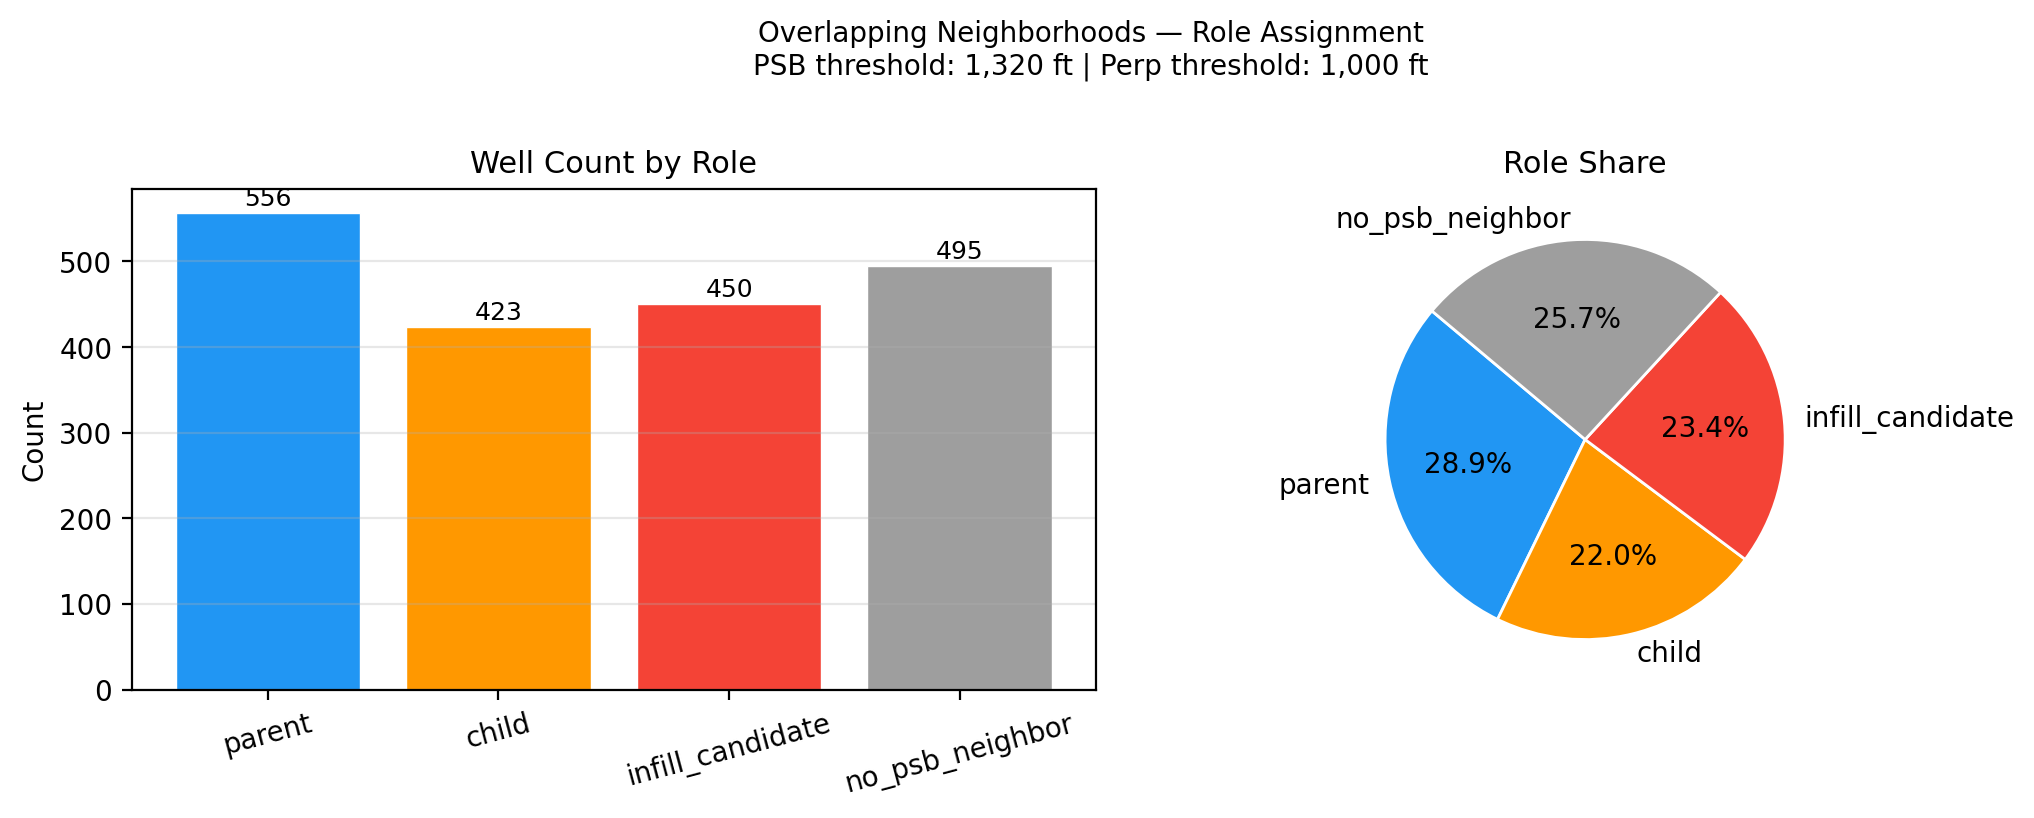

In [14]:
role_counts = df_out['role'].value_counts()
role_labels_ordered = ['parent', 'child', 'infill_candidate', 'no_psb_neighbor']
role_counts = role_counts.reindex(
    [r for r in role_labels_ordered if r in role_counts.index]
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Bar chart
ax = axes[0]
bars = ax.bar(
    role_counts.index,
    role_counts.values,
    color=[ROLE_COLORS.get(r, '#607D8B') for r in role_counts.index],
    edgecolor='white', linewidth=0.5,
)
for bar, count in zip(bars, role_counts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 3,
        f'{count:,}',
        ha='center', va='bottom', fontsize=9,
    )
ax.set_title('Well Count by Role', fontsize=11)
ax.set_ylabel('Count')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=15)
ax.grid(axis='y', alpha=0.3)

# Pie chart
ax = axes[1]
ax.pie(
    role_counts.values,
    labels=role_counts.index,
    colors=[ROLE_COLORS.get(r, '#607D8B') for r in role_counts.index],
    autopct='%1.1f%%',
    startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1},
)
ax.set_title('Role Share', fontsize=11)

plt.suptitle(
    f'Overlapping Neighborhoods — Role Assignment\n'
    f'PSB threshold: {CFG["parallel_eps_ft"]:,} ft | '
    f'Perp threshold: {CFG["perp_eps_ft"]:,} ft',
    fontsize=10, y=1.01,
)
plt.tight_layout()
plt.show()

### 9.2  Parent Distance Distribution (children only)

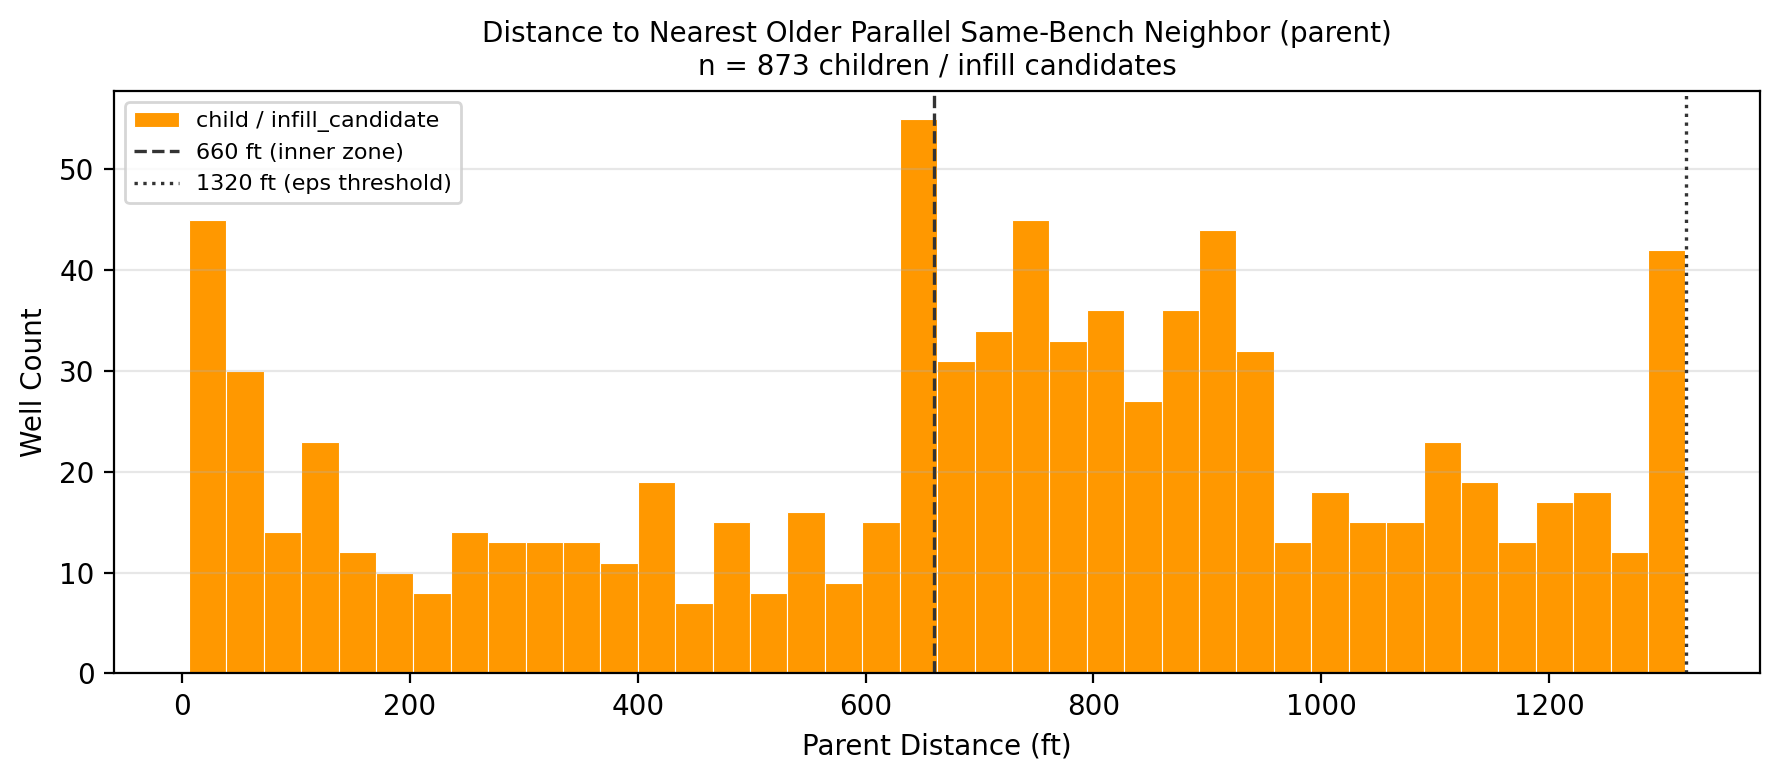

count     873.0
mean      697.5
std       371.0
min         5.8
25%       420.9
50%       742.5
75%       944.8
max     1,319.9


In [15]:
df_children = df_out[df_out['role'].isin(['child', 'infill_candidate'])].dropna(subset=['parent_dist_ft'])

fig, ax = plt.subplots(figsize=(9, 4))

ax.hist(
    df_children['parent_dist_ft'],
    bins=40,
    color='#FF9800', edgecolor='white', linewidth=0.4,
    label='child / infill_candidate',
)

# Reference lines
for xval, label, ls in [
    (CFG['parallel_inner_ft'], f"{CFG['parallel_inner_ft']} ft (inner zone)",  '--'),
    (CFG['parallel_eps_ft'],   f"{CFG['parallel_eps_ft']} ft (eps threshold)", ':'),
]:
    ax.axvline(xval, color='#333', linestyle=ls, linewidth=1.2, label=label)

ax.set_xlabel('Parent Distance (ft)', fontsize=10)
ax.set_ylabel('Well Count', fontsize=10)
ax.set_title(
    f'Distance to Nearest Older Parallel Same-Bench Neighbor (parent)\n'
    f'n = {len(df_children):,} children / infill candidates',
    fontsize=10,
)
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(df_children['parent_dist_ft'].describe().to_string())

### 9.3  Neighbor Count Distribution by Role

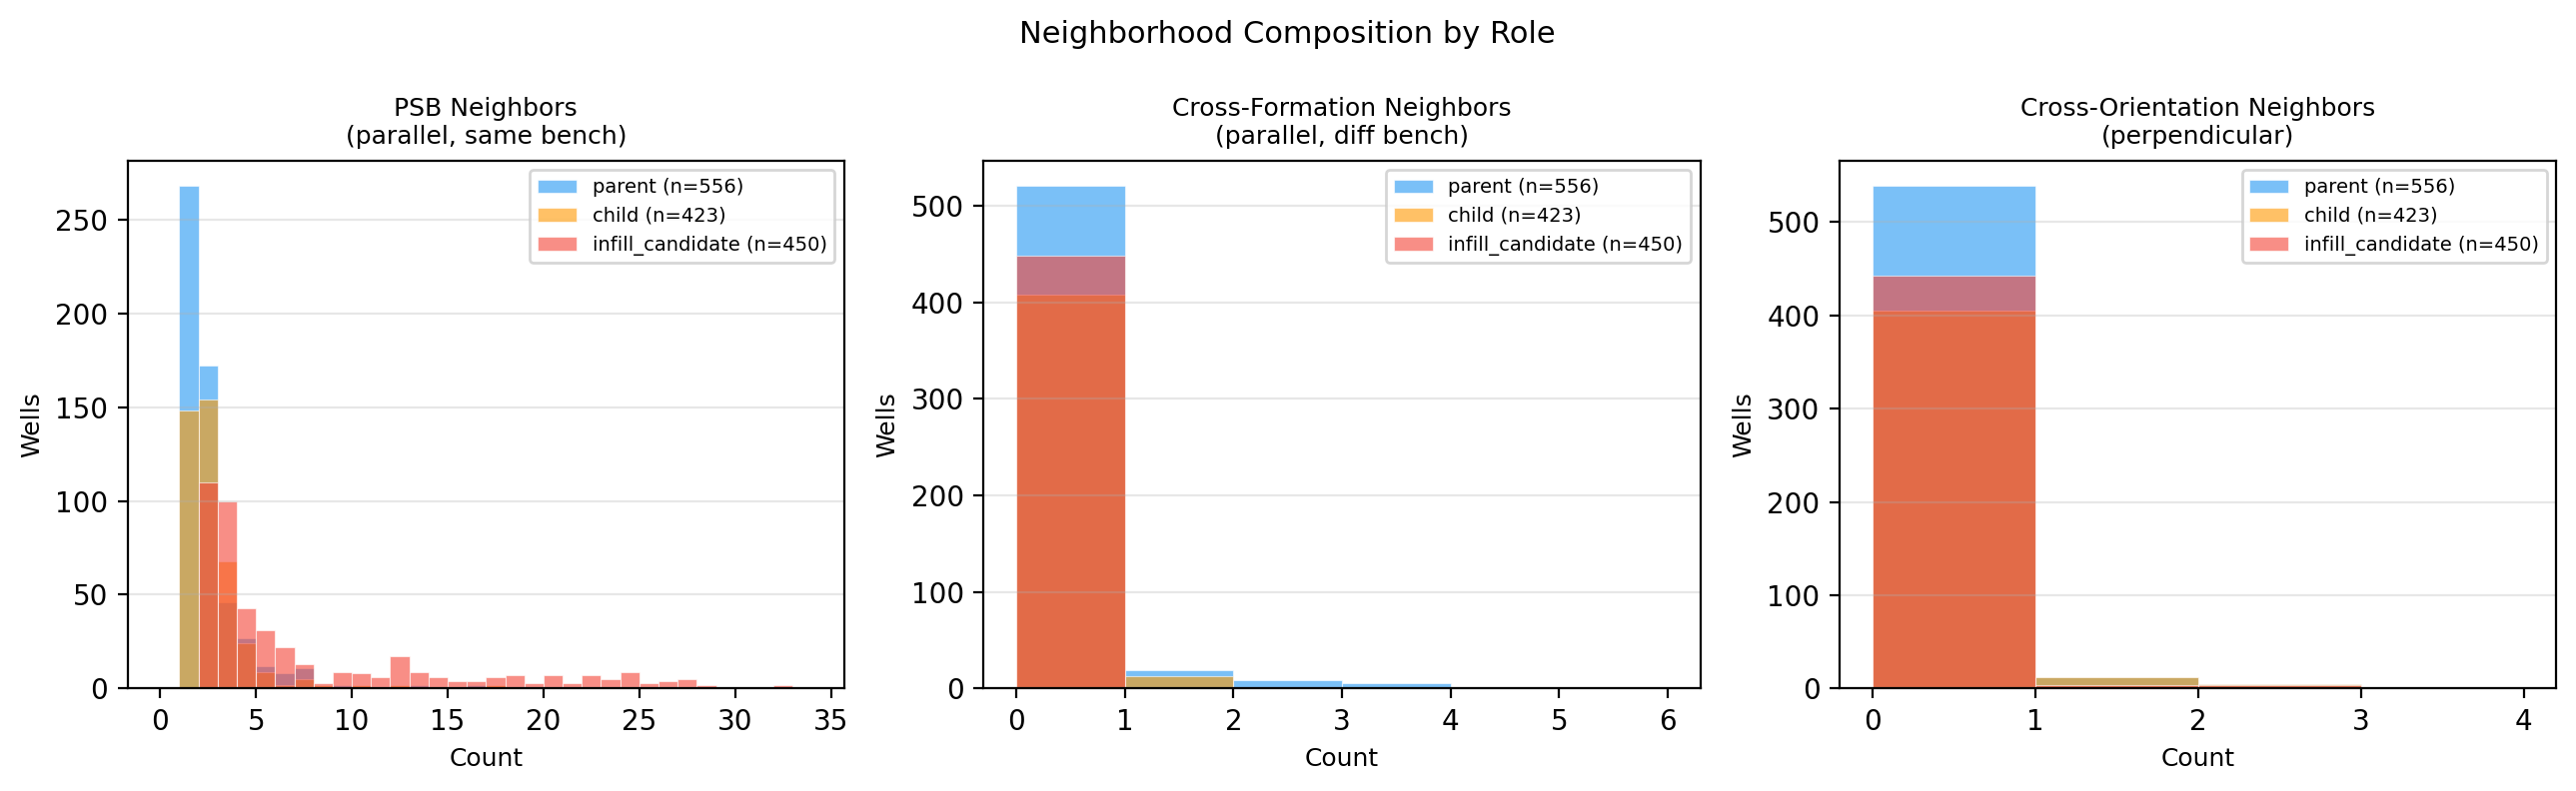

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=False)

count_cols = [
    ('n_psb_neighbors',      'PSB Neighbors\n(parallel, same bench)'),
    ('n_cross_formation',    'Cross-Formation Neighbors\n(parallel, diff bench)'),
    ('n_cross_orientation',  'Cross-Orientation Neighbors\n(perpendicular)'),
]

roles_to_plot = ['parent', 'child', 'infill_candidate']

for ax, (col, title) in zip(axes, count_cols):
    for role in roles_to_plot:
        sub = df_out[df_out['role'] == role][col].dropna()
        if sub.empty:
            continue
        ax.hist(
            sub,
            bins=range(0, int(sub.max()) + 2),
            alpha=0.6,
            color=ROLE_COLORS[role],
            label=f'{role} (n={len(sub):,})',
            edgecolor='white', linewidth=0.4,
        )
    ax.set_title(title, fontsize=9)
    ax.set_xlabel('Count', fontsize=9)
    ax.set_ylabel('Wells', fontsize=9)
    ax.legend(fontsize=7)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Neighborhood Composition by Role', fontsize=11)
plt.tight_layout()
plt.show()

### 9.4  Geographic Map — Wells Colored by Role

Uses midpoint lat/lon from the heel-toe-midpoint file.

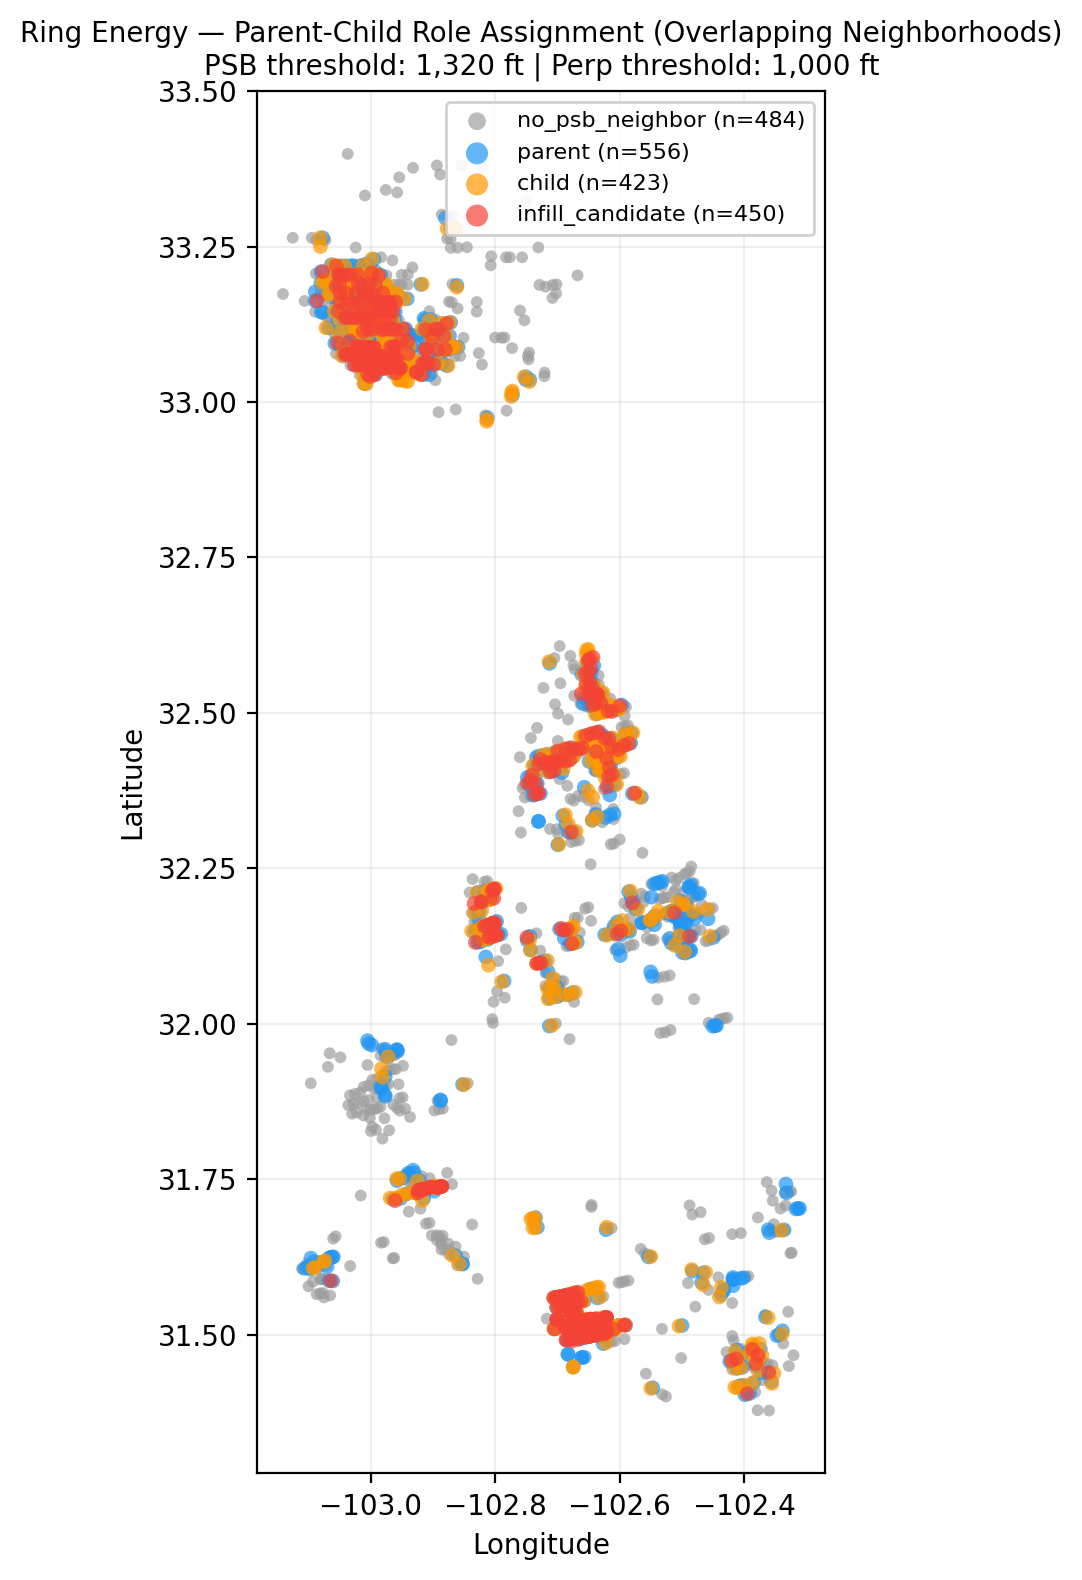

In [17]:
df_map = df_out.dropna(subset=['mid_Lat', 'mid_Lon'])

fig, ax = plt.subplots(figsize=(11, 8))

for role in ['no_psb_neighbor', 'parent', 'child', 'infill_candidate']:
    sub = df_map[df_map['role'] == role]
    if sub.empty:
        continue
    ax.scatter(
        sub['mid_Lon'], sub['mid_Lat'],
        c=ROLE_COLORS[role],
        s=18 if role == 'no_psb_neighbor' else 28,
        alpha=0.7,
        label=f'{role} (n={len(sub):,})',
        edgecolors='none',
        zorder=3 if role != 'no_psb_neighbor' else 1,
    )

ax.set_xlabel('Longitude', fontsize=10)
ax.set_ylabel('Latitude', fontsize=10)
ax.set_title(
    'Ring Energy — Parent-Child Role Assignment (Overlapping Neighborhoods)\n'
    f'PSB threshold: {CFG["parallel_eps_ft"]:,} ft | '
    f'Perp threshold: {CFG["perp_eps_ft"]:,} ft',
    fontsize=10,
)
ax.legend(fontsize=8, markerscale=1.5, framealpha=0.9)
ax.grid(True, alpha=0.2)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

### 9.5  Role Breakdown by Bench (Formation)

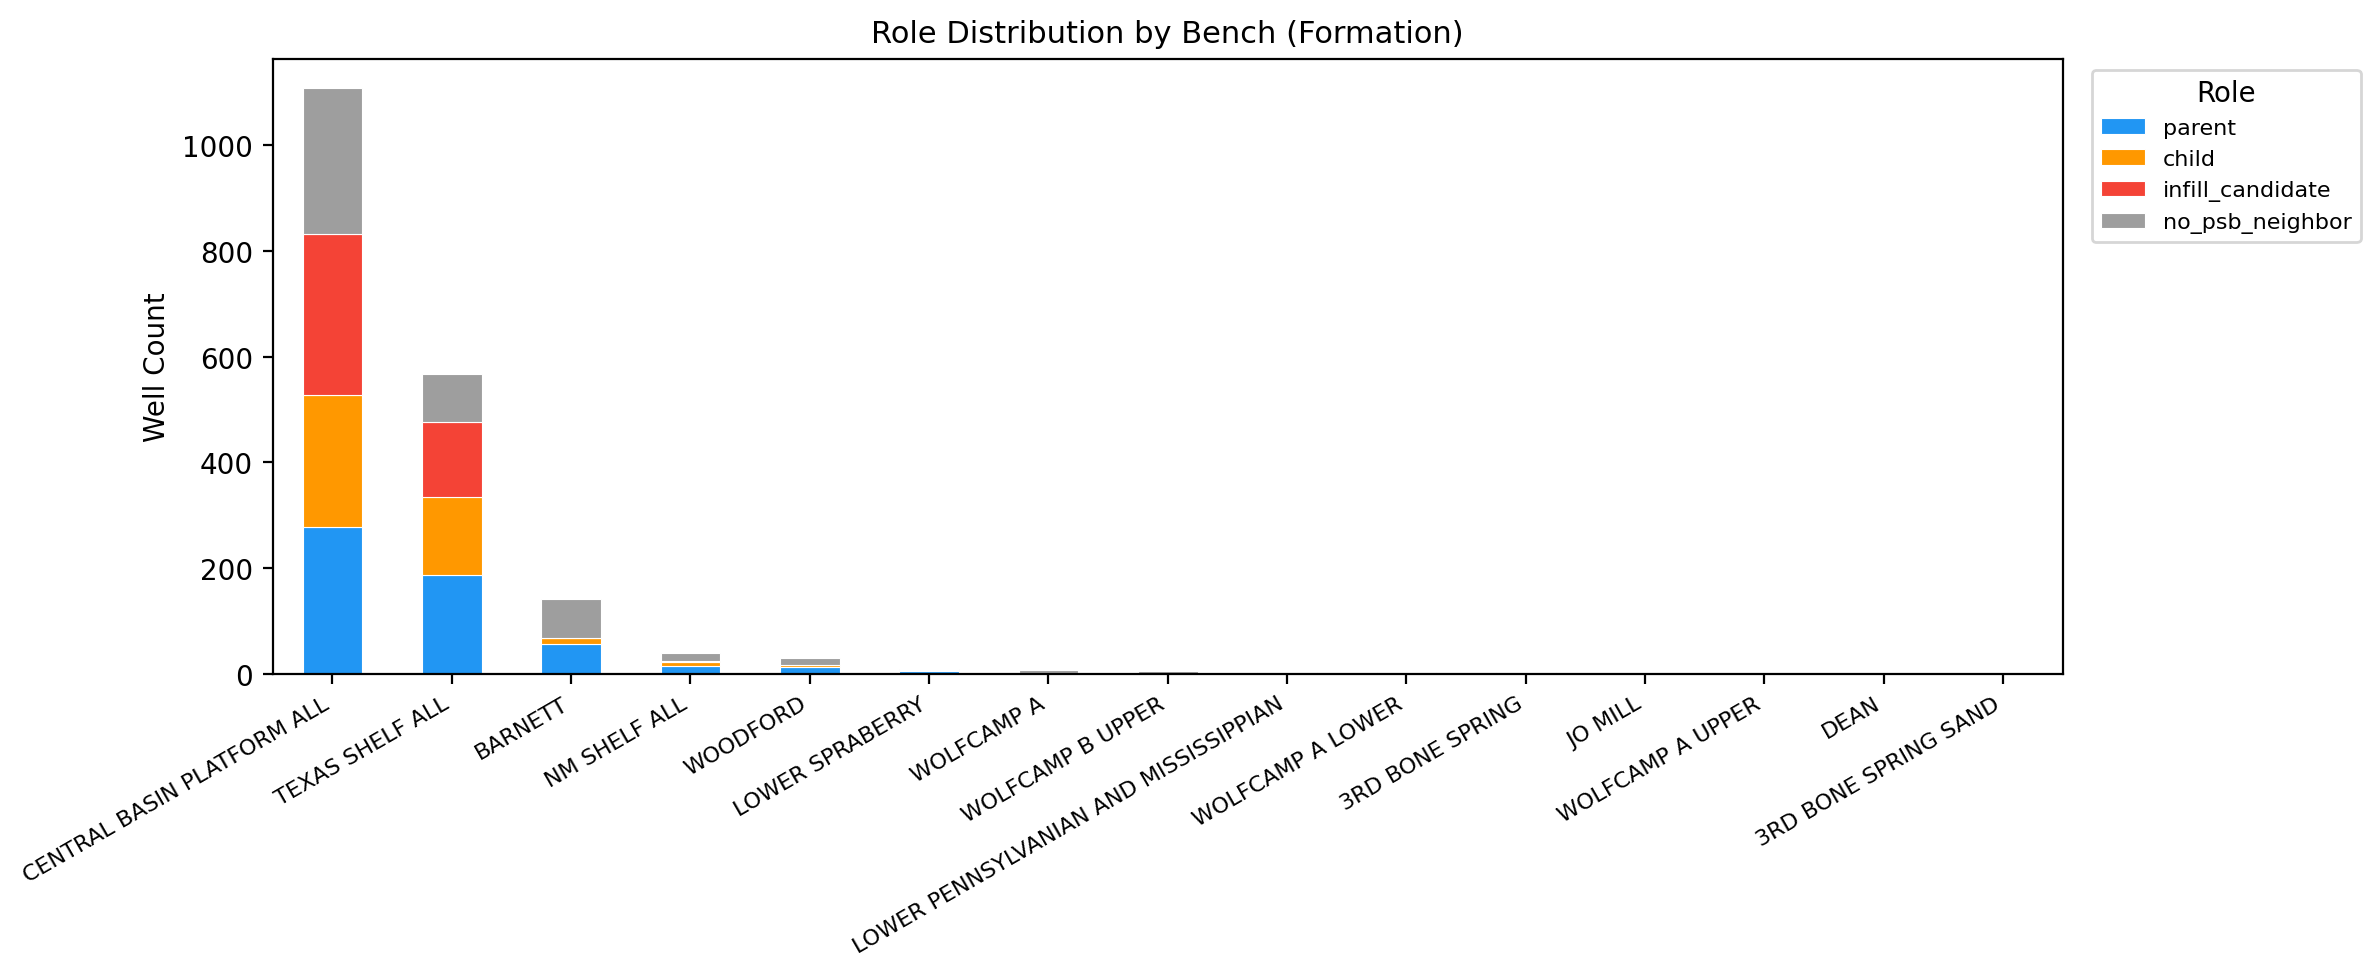

Role share per bench (%):
role                                   parent  child  infill_candidate  no_psb_neighbor
bench                                                                                  
CENTRAL BASIN PLATFORM ALL               25.0   22.6              27.4             25.0
TEXAS SHELF ALL                          32.9   26.1              25.0             16.0
BARNETT                                  39.7    7.8               0.7             51.8
NM SHELF ALL                             35.9   23.1               5.1             35.9
WOODFORD                                 40.0   13.3               3.3             43.3
LOWER SPRABERRY                          66.7   11.1               0.0             22.2
WOLFCAMP A                               25.0    0.0               0.0             75.0
WOLFCAMP B UPPER                          0.0    0.0               0.0            100.0
LOWER PENNSYLVANIAN AND MISSISSIPPIAN     0.0    0.0               0.0            100.0
WOLFCA

In [18]:
pivot = (
    df_out.groupby(['bench', 'role'])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=[r for r in role_labels_ordered if r in df_out['role'].unique()], fill_value=0)
)

# Sort by total wells per bench
pivot = pivot.loc[pivot.sum(axis=1).sort_values(ascending=False).index]

pivot.plot(
    kind='bar',
    stacked=True,
    color=[ROLE_COLORS.get(c, '#607D8B') for c in pivot.columns],
    edgecolor='white', linewidth=0.4,
    figsize=(12, 5),
)
plt.title('Role Distribution by Bench (Formation)', fontsize=11)
plt.xlabel('')
plt.ylabel('Well Count')
plt.xticks(rotation=30, ha='right', fontsize=8)
plt.legend(title='Role', fontsize=8, bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Percent table
pct = pivot.div(pivot.sum(axis=1), axis=0).mul(100).round(1)
print('Role share per bench (%):')
print(pct.to_string())

### 9.6  Temporal Profile — Completion Year by Role

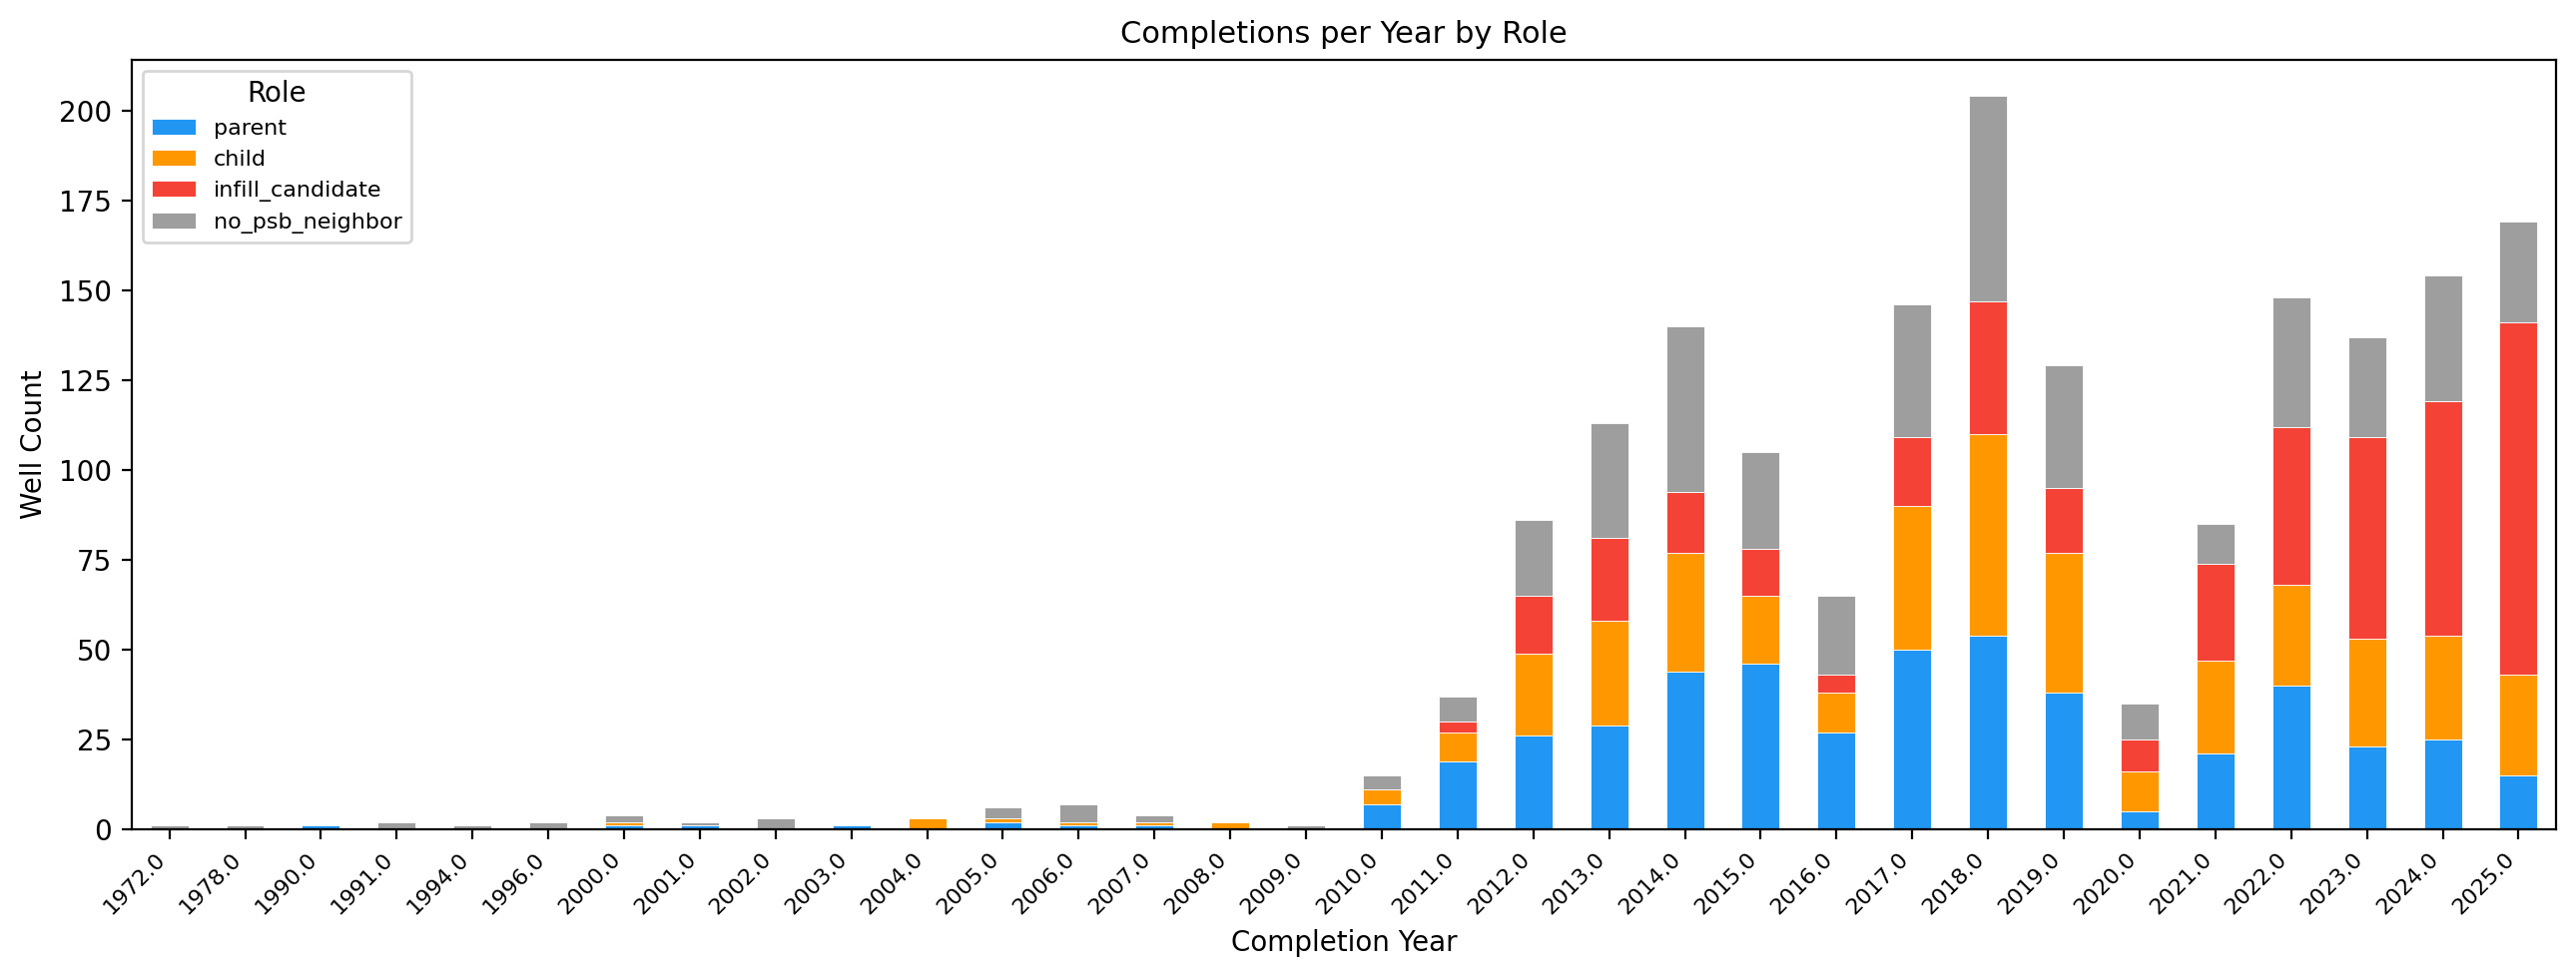

In [19]:
df_out['comp_year'] = df_out['comp_date'].dt.year

pivot_year = (
    df_out.dropna(subset=['comp_year'])
    .groupby(['comp_year', 'role'])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=[r for r in role_labels_ordered if r in df_out['role'].unique()], fill_value=0)
)

pivot_year.plot(
    kind='bar',
    stacked=True,
    color=[ROLE_COLORS.get(c, '#607D8B') for c in pivot_year.columns],
    edgecolor='white', linewidth=0.3,
    figsize=(13, 5),
)
plt.title('Completions per Year by Role', fontsize=11)
plt.xlabel('Completion Year')
plt.ylabel('Well Count')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.legend(title='Role', fontsize=8)
plt.tight_layout()
plt.show()

## 10. Diagnostics — Sample Neighborhood Detail

For a given focal well, print its full neighborhood for manual validation.

In [20]:
def print_neighborhood(uwi, df_nbhd: pd.DataFrame, df_out: pd.DataFrame, date_lookup: dict):
    """Pretty-print the full neighborhood of a focal well."""
    # Summary row
    row = df_out[df_out['uwi'] == uwi]
    if row.empty:
        print(f'UWI {uwi} not found in output table.')
        return
    row = row.iloc[0]

    print(f'═══ Focal well: {uwi} ═══')
    print(f'  Name:        {row.get("well_name", "—")}')
    print(f'  Bench:       {row.get("bench", "—")}')
    print(f'  Lease:       {row.get("lease_name", "—")}')
    print(f'  Comp date:   {str(row.get("comp_date", "—"))[:10]}')
    print(f'  Role:        {row["role"]}', end='')
    if row.get('child_gen'):
        print(f' ({row["child_gen"]})', end='')
    print()
    if pd.notna(row.get('parent_uwi')):
        print(f'  Parent:      {row["parent_uwi"]} @ {row["parent_dist_ft"]:.0f} ft '
              f'(comp {str(row.get("parent_comp_date", "—"))[:10]})')
    print(f'  PSB neighbors:         {int(row["n_psb_neighbors"])}')
    print(f'  Cross-formation:       {int(row.get("n_cross_formation", 0))}')
    print(f'  Cross-orientation:     {int(row.get("n_cross_orientation", 0))}')

    # Neighbor detail
    nbrs = df_nbhd[df_nbhd['well_i'] == uwi].sort_values('dist_for_threshold')
    if nbrs.empty:
        print('  (no neighbors within threshold)')
        return

    print(f'\n  Neighbor detail ({len(nbrs)} total):')
    display_cols = ['well_k', 'rel_type', 'dist_for_threshold', 'angle_deg',
                    'bench_k', 'comp_date_k', 'k_is_older', 'overlap_pct_k']
    display_cols = [c for c in display_cols if c in nbrs.columns]
    print(nbrs[display_cols].to_string(index=False))


# ── Example: pick first parent well for demo ──────────────────────────────────
example_uwi = df_out[df_out['role'] == 'parent']['uwi'].iloc[0]
print_neighborhood(example_uwi, df_nbhd, df_out, date_lookup)

print()
# ── Example: pick first child well ────────────────────────────────────────────
example_child = df_out[df_out['role'] == 'child']['uwi'].iloc[0]
print_neighborhood(example_child, df_nbhd, df_out, date_lookup)

═══ Focal well: 42475389560000 ═══
  Name:        KING GEORGE 7707WH
  Bench:       WOODFORD
  Lease:       KING GEORGE
  Comp date:   NaT
  Role:        parent (nan)
  PSB neighbors:         1
  Cross-formation:       0
  Cross-orientation:     0

  Neighbor detail (1 total):
        well_k            rel_type  dist_for_threshold  angle_deg  bench_k comp_date_k  k_is_older  overlap_pct_k
42475389570000 parallel_same_bench             1,311.2        0.0 WOODFORD         NaT       False            1.0

═══ Focal well: 42501370590000 ═══
  Name:        BRUSHY BILL 707-730 2XH
  Bench:       TEXAS SHELF ALL
  Lease:       BRUSHY BILL 707-730
  Comp date:   2019-01-20
  Role:        child (late_child)
  Parent:      42501368000000 @ 1206 ft (comp 2017-05-21)
  PSB neighbors:         2
  Cross-formation:       0
  Cross-orientation:     0

  Neighbor detail (2 total):
        well_k            rel_type  dist_for_threshold  angle_deg         bench_k comp_date_k  k_is_older  overlap_pct_k
425

In [21]:
df_nbhd

,well_i,well_k,bench_i,bench_k,LL_i,LL_k,overlap_pct_i,overlap_pct_k,tvd_i,tvd_k,hz_effective,3D_dist_effective,vertical_dist,angle_deg,pair_alignment,min_distance_ft,same_bench,rel_type,dist_for_threshold,threshold_ft,in_neighborhood,comp_date_i,comp_date_k,k_is_older,days_diff
0,30025421210000,30025426220000,NM SHELF ALL,NM SHELF ALL,"4,322.0","4,335.5",1.0,1.0,"5,378.9","5,404.9","1,251.2","1,251.5",26.1,2.1,parallel_like,NaN,True,parallel_same_bench,"1,251.2",1320,True,2014-12-04,2015-08-25,False,-264.0
10,30025426220000,30025421210000,NM SHELF ALL,NM SHELF ALL,"4,335.5","4,322.0",1.0,1.0,"5,404.9","5,378.9","1,251.3","1,251.5",26.1,2.1,parallel_like,NaN,True,parallel_same_bench,"1,251.3",1320,True,2015-08-25,2014-12-04,True,264.0
33,30025449160000,30025453300000,NM SHELF ALL,NM SHELF ALL,"5,210.4","5,033.3",0.0,0.0,"5,183.2","5,203.2","1,243.6","1,243.8",20.0,2.4,parallel_like,NaN,True,parallel_same_bench,"1,243.6",1320,True,2018-08-01,2019-01-31,False,-183.0
36,30025449160000,30025463300000,NM SHELF ALL,NM SHELF ALL,"5,210.4","5,187.4",1.0,1.0,"5,183.2","5,162.6","1,096.5","1,096.7",20.6,2.5,parallel_like,NaN,True,parallel_same_bench,"1,096.5",1320,True,2018-08-01,2019-11-09,False,-465.0
116,30025463300000,30025449160000,NM SHELF ALL,NM SHELF ALL,"5,187.4","5,210.4",1.0,1.0,"5,162.6","5,183.2","1,097.0","1,097.2",20.6,2.5,parallel_like,NaN,True,parallel_same_bench,"1,097.0",1320,True,2019-11-09,2018-08-01,True,465.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96221,42501370610000,42501373980000,TEXAS SHELF ALL,TEXAS SHELF ALL,"4,471.3","5,231.6",0.0,0.0,"5,295.7","5,373.1","1,154.1","1,156.7",77.4,2.8,parallel_like,NaN,True,parallel_same_bench,"1,154.1",1320,True,2019-01-30,2022-10-06,False,"-1,345.0"
96280,42501373090000,42501374030000,TEXAS SHELF ALL,TEXAS SHELF ALL,"5,156.2","5,437.5",0.0,0.0,"5,287.1","5,329.4",252.3,255.8,42.3,2.6,parallel_like,NaN,True,parallel_same_bench,252.3,1320,True,2021-11-13,2022-10-26,False,-347.0
96786,42501374030000,42501374250000,TEXAS SHELF ALL,TEXAS SHELF ALL,"5,437.5","5,167.8",0.0,0.0,"5,329.4","5,345.3",779.8,779.9,15.9,2.8,parallel_like,NaN,True,parallel_same_bench,779.8,1320,True,2022-10-26,2023-05-01,False,-187.0
98227,42501366990000,42501375540000,TEXAS SHELF ALL,TEXAS SHELF ALL,"5,262.3","7,854.7",0.0,0.0,"5,306.9","5,295.4",405.0,405.2,11.5,1.5,parallel_like,NaN,True,parallel_same_bench,405.0,1320,True,2016-08-28,2024-08-23,False,"-2,917.0"


In [22]:
df_out

,uwi,well_name,lease_name,operator,bench,comp_date,role,child_gen,parent_uwi,parent_dist_ft,parent_comp_date,days_since_parent,n_psb_neighbors,n_older_psb_neighbors,n_inner_zone_neighbors,n_cross_formation,n_cross_formation_pre_existing,n_cross_formation_post,min_dist_cross_formation_ft,n_cross_orientation,n_cross_orientation_pre_existing,n_cross_orientation_post,min_dist_cross_orientation_ft,n_oblique_same_bench,avg_hz_spacing_ft,group_size,lateral_length_ft,tvd,fluid_intensity_bbl_per_ft,proppant_intensity_lbs_per_ft,cum_oil_180d,cum_oil_365d,cum_oil_180d_per_ft,cum_oil_365d_per_ft,rsv_cat,surface_lat,surface_lon,mid_Lat,mid_Lon,comp_year
0,42501367160100,SLIM HONEYCUTT 608 4XH,SLIM HONEYCUTT 608,RILEY EXPLORATION PERMIAN,TEXAS SHELF ALL,2017-01-17,no_psb_neighbor,NaN,NaN,NaN,NaT,NaN,0,0,0,0,0,0,NaN,0,0,0,NaN,0,NaN,1.0,"4,638.0","5,311.7",5.4,NaN,"2,119.0","2,971.0",0.5,0.6,01PDP,33.1,-102.9,33.1,-102.9,"2,017.0"
1,42003385790000,STATE FI 11H,STATE FI,LIME ROCK,CENTRAL BASIN PLATFORM ALL,2000-04-15,no_psb_neighbor,NaN,NaN,NaN,NaT,NaN,0,0,0,0,0,0,NaN,2,0,2,23.1,0,NaN,1.0,"1,869.0","10,683.1",NaN,NaN,"1,975.0","5,955.0",1.1,3.2,02PA,32.1,-102.6,32.1,-102.6,"2,000.0"
2,42475389480000,KING GEORGE 7705WH,KING GEORGE,CONOCOPHILLIPS,WOODFORD,NaT,no_psb_neighbor,NaN,NaN,NaN,NaT,NaN,0,0,0,0,0,0,NaN,0,0,0,NaN,0,"1,330.2",2.0,"14,904.0","14,950.6",NaN,NaN,NaN,NaN,NaN,NaN,03PUD,31.6,-103.1,31.6,-103.1,NaN
3,42103375340000,WADDELL TR A 4049H,WADDELL TR A,BLACKBEARD OPERATING,CENTRAL BASIN PLATFORM ALL,2025-09-15,infill_candidate,NaN,42103373410000,87.9,2025-07-31,46.0,25,24,11,0,0,0,NaN,0,0,0,NaN,0,"1,088.7",6.0,"11,413.0","3,408.9",4.4,222.2,"17,956.2","17,956.2",1.6,1.6,01PDP,31.5,-102.6,31.5,-102.6,"2,025.0"
4,42475389560000,KING GEORGE 7707WH,KING GEORGE,CONOCOPHILLIPS,WOODFORD,NaT,parent,NaN,NaN,NaN,NaT,NaN,1,0,0,0,0,0,NaN,0,0,0,NaN,0,"1,320.7",3.0,"15,035.0","14,815.6",NaN,NaN,NaN,NaN,NaN,NaN,03PUD,31.6,-103.1,31.6,-103.1,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1919,42165324830100,WHARTON UNIT 113,WHARTON UNIT,MACH NATURAL RESOURCES LP,CENTRAL BASIN PLATFORM ALL,NaT,no_psb_neighbor,NaN,NaN,NaN,NaT,NaN,0,0,0,0,0,0,NaN,1,0,1,48.5,0,NaN,1.0,"1,021.0","5,954.5",NaN,NaN,NaN,NaN,NaN,NaN,02PDNP,32.6,-102.7,32.6,-102.7,NaN
1920,42003034550100,SHAFTER LAKE /SAN ANDRES/ UNIT 96W,SHAFTER LAKE /SAN ANDRES/ UNIT,HILCORP,CENTRAL BASIN PLATFORM ALL,2010-10-18,no_psb_neighbor,NaN,NaN,NaN,NaT,NaN,0,0,0,0,0,0,NaN,0,0,0,NaN,0,NaN,1.0,"2,312.0","4,625.7",NaN,NaN,NaN,NaN,NaN,NaN,02PA,32.3,-102.6,32.3,-102.6,"2,010.0"
1921,42003434610100,UNIVERSITY 24A 3,UNIVERSITY 24A,CRESCENT ENERGY COMPANY,CENTRAL BASIN PLATFORM ALL,NaT,no_psb_neighbor,NaN,NaN,NaN,NaT,NaN,0,0,0,0,0,0,NaN,0,0,0,NaN,0,NaN,1.0,"1,763.0","4,517.7",NaN,NaN,NaN,NaN,NaN,NaN,02PA,32.2,-102.6,32.2,-102.6,NaN
1922,42003416510100,UNIVERSITY BLOCK 9 8A,UNIVERSITY BLOCK 9,EXXON,CENTRAL BASIN PLATFORM ALL,2015-09-03,no_psb_neighbor,NaN,NaN,NaN,NaT,NaN,0,0,0,0,0,0,NaN,0,0,0,NaN,0,NaN,1.0,"2,560.0","10,607.7",NaN,NaN,576.7,928.8,0.2,0.4,02PA,32.2,-102.6,32.2,-102.6,"2,015.0"


## 11. Export

In [23]:
out_path = CFG['output_dir'] / 'overlapping_neighborhoods_roles.csv'
df_out.to_csv(out_path, index=False)
print(f'Saved {len(df_out):,} rows → {out_path}')

# Also save the full neighborhood edge table (useful for network analysis)
nbhd_edge_path = CFG['output_dir'] / 'overlapping_neighborhoods_edges.csv'
edge_cols = [
    'well_i', 'well_k', 'rel_type',
    'dist_for_threshold', 'threshold_ft',
    'angle_deg', 'pair_alignment',
    'bench_i', 'bench_k',
    'overlap_pct_i', 'overlap_pct_k',
    'comp_date_i', 'comp_date_k',
    'k_is_older', 'days_diff',
]
edge_cols = [c for c in edge_cols if c in df_nbhd.columns]
df_nbhd[edge_cols].to_csv(nbhd_edge_path, index=False)
print(f'Saved {len(df_nbhd):,} neighborhood edges → {nbhd_edge_path}')

Saved 1,924 rows → C:\Users\ApoorvaSaxen_ct6z7vh\OneDrive - Bandera Group\Desktop\Project AP\05. Spacing Study\03. Ring Energy\04. Spacing Results\v2\overlapping_neighborhoods_roles.csv
Saved 5,848 neighborhood edges → C:\Users\ApoorvaSaxen_ct6z7vh\OneDrive - Bandera Group\Desktop\Project AP\05. Spacing Study\03. Ring Energy\04. Spacing Results\v2\overlapping_neighborhoods_edges.csv


---
## Summary

This notebook implements the **Overlapping Neighborhoods** approach for parent-child well role
assignment using pre-computed pairwise spacing results.

### Outputs
| File | Description |
|---|---|
| `overlapping_neighborhoods_roles.csv` | One row per well with role, parent, and cross-interference counts |
| `overlapping_neighborhoods_edges.csv` | Neighborhood edge table (all pairs within threshold, both directions) |

### Next Steps
1. **Validate** role assignments against known parent-child relationships from completion reports
2. **Production analysis** — compare child EUR / 180-day oil vs parent for same spacing unit
3. **Integrate with Phase 3 clustering** — use these neighborhoods as the analytical layer
   on top of the diameter-constrained spacing-unit clusters
4. **Threshold sensitivity** — re-run with `parallel_eps_ft = 660` (inner zone only) and
   compare role counts to assess threshold sensitivity
5. **Lease filtering** — add `lease_name` as a hard constraint so cross-lease pairs are flagged
   but not used for primary role assignment
